# Summary

This notebook contains a summary of the entire repository for the BNPL project

In [58]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import Point
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType

In [59]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

## Preprocessing

On preprocessing all the data the following records are left in the dataset

In [60]:
# merchant data set
df_merchants = spark.read.parquet('.././data/curated/df_merchants')
df_merchants.count()

4026

In [61]:
# consumer
df_customers = spark.read.parquet('.././data/curated/df_customers')
df_customers.count()

34864

In [62]:
# full transactions (after join w merchant and consumers)
df_transactions = spark.read.parquet('.././data/curated/df_transactions')
df_transactions.count()

71816

All tables have been checked to ensure that all records are valid. Invalid merchants were removed.

Joining the original data:
The data was joined on order_datetime and ids for merchants and consumers

In [63]:
df_transactions.printSchema()

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [64]:
df_transactions.filter(F.isnull('avg_merchant_fraud_prob')).count()

65518

In [65]:
df_transactions.filter(F.isnull('fraud_probability')).count()

0

13610826 merchant frauds were null and 13543038 consumer frauds were null and needed to be imputed.

## External datasets:
**Census Data:** This data was combined with our original data using consumer postocde and was used to retrieve features such as household size, family earnings and age.

In [66]:
final_merged = spark.read.parquet('.././data/curated/final_external_enriched')
final_merged.show()

+--------------+--------+------------+-------+------------------+--------------------+-----------+------------------+---------------------+---------------+--------------------+-----+------+--------------------+--------------------+--------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+-------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+----------+--------------+------------------+----------------+--------------+---------------+------------------+--------------+-------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|           name|             address|state|gender|       merchant_

In [67]:
final_merged.printSchema()

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- SA

In [68]:
final_merged.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("SA2_CODE_2021").isNull().cast("int")).alias("missing_census"),
    F.sum(F.col("poa_irsad_score").isNull().cast("int")).alias("missing_seifa"),
    F.sum(F.col("rba_cash_rate_pct").isNull().cast("int")).alias("missing_rba"),
    F.sum(F.col("avg_merchant_fraud_prob").isNull().cast("int")).alias("missing_fraud_label"),
).show()

+----------+--------------+-------------+-----------+-------------------+
|total_rows|missing_census|missing_seifa|missing_rba|missing_fraud_label|
+----------+--------------+-------------+-----------+-------------------+
|     93431|         37544|        12367|          0|              85265|
+----------+--------------+-------------+-----------+-------------------+



## Exploratory Analysis

This section contains a summary on some of the features studied, `tbc`

**Transaction Level Distributions**

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


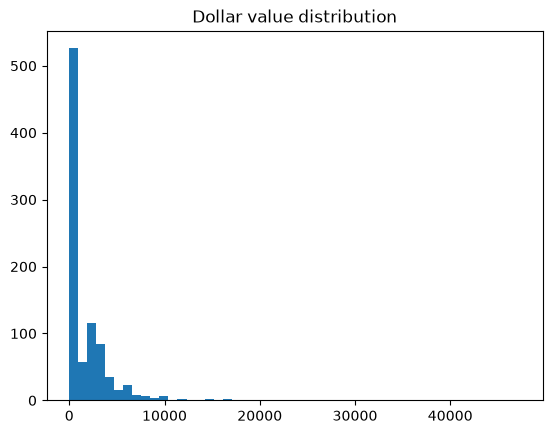

In [69]:
pdf = final_merged.select("dollar_value").sample(0.01).toPandas()  # sample first, full table is large
plt.hist(pdf["dollar_value"], bins=50)
plt.title("Dollar value distribution")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


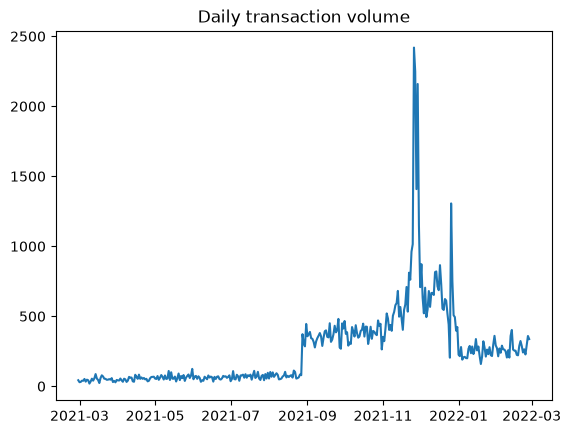

In [70]:
daily = (
    final_merged
    .groupBy("order_datetime")
    .agg(F.count("*").alias("n_txn"), F.sum("dollar_value").alias("total_value"))
    .orderBy("order_datetime")
    .toPandas()
)
plt.plot(daily["order_datetime"], daily["n_txn"])
plt.title("Daily transaction volume")
plt.show()

**Merchant Landscape**

In [71]:
(final_merged.groupBy("category_group")
    .agg(F.sum("dollar_value").alias("revenue"), F.countDistinct("merchant_abn").alias("n_merchants"))
    .orderBy(F.desc("revenue"))
    .show(20, truncate=False))

+------------------------+--------------------+-----------+
|category_group          |revenue             |n_merchants|
+------------------------+--------------------+-----------+
|antiques_art_craft      |4.333526564287774E7 |358        |
|jewelry                 |2.694240381114229E7 |225        |
|tv_media_telecom        |2.1990607491991058E7|271        |
|vehicle                 |1.9257669184479527E7|260        |
|equipment_rental_leasing|1.5962822602050858E7|127        |
|furniture_home          |1.1356687417931266E7|146        |
|outdoor_supply          |9125094.909304183   |157        |
|gardening               |8373438.220663373   |260        |
|gifts_hobby_novelty     |7672232.53192921    |292        |
|music                   |2379166.4261947465  |133        |
|health_beauty           |1696905.5072584967  |344        |
|technology              |1547137.9737849594  |279        |
|office_stationery       |1312246.972576325   |107        |
|footwear                |541087.8992828

**Consumer Demographics**

In [72]:
final_merged.groupBy("state", "gender").agg(F.countDistinct("consumer_id").alias("n_consumers")).show()

+-----+-----------+-----------+
|state|     gender|n_consumers|
+-----+-----------+-----------+
|   WA|       Male|       1422|
|  QLD|       Male|       1280|
|  ACT|     Female|         84|
|  TAS|Undisclosed|         77|
|   SA|     Female|        984|
|  VIC|Undisclosed|        470|
|   WA|Undisclosed|        305|
|   NT|     Female|        124|
|  NSW|Undisclosed|        559|
|  NSW|     Female|       2480|
|  QLD|     Female|       1292|
|   NT|Undisclosed|         28|
|   SA|Undisclosed|        250|
|   NT|       Male|        114|
|  VIC|       Male|       2050|
|   WA|     Female|       1367|
|  ACT|Undisclosed|         20|
|  VIC|     Female|       2009|
|  NSW|       Male|       2586|
|  QLD|Undisclosed|        291|
+-----+-----------+-----------+
only showing top 20 rows


**Socioeconomic**

In [73]:
(final_merged
    .filter(F.col("poa_irsad_decile").isNotNull())
    .groupBy("poa_irsad_decile")
    .agg(
        F.avg("dollar_value").alias("avg_spend"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("Median_tot_hhd_inc_weekly").alias("avg_hhd_income"),
        F.avg("prop_18_34").alias("avg_prop_young"),
    )
    .orderBy("poa_irsad_decile")
    .show())

+----------------+------------------+------------------+------------------+-------------------+
|poa_irsad_decile|         avg_spend|    avg_fraud_prob|    avg_hhd_income|     avg_prop_young|
+----------------+------------------+------------------+------------------+-------------------+
|             1.0|1830.0291455215354|14.702307422885887|1261.3733852778348|0.21311053693984655|
|             2.0|1907.8863438985225|14.576353395097417|1294.9047120418847|0.18994429319371728|
|             3.0|1879.0042281987662|14.737973302306106|1400.0121227753418|0.19132563315425943|
|             4.0|1837.8383755351106|14.567424400047502|1475.8741627765376|0.20117145753091437|
|             5.0|1881.4544804314926|14.927305087055096|1648.8553153153152|0.20446612266857972|
|             6.0|1872.1374466937605|14.933262511491808|1732.4562804284324| 0.2180446613312513|
|             7.0|1838.2143369849805| 14.42427959476939|1797.7740842684734|0.21291442287177292|
|             8.0|1762.7464747210543|14.

**RBA Rate**

In [74]:
(final_merged.groupBy("rba_rate_hike_day")
    .agg(F.avg("dollar_value").alias("avg_txn_value"), F.count("*").alias("n_txn"))
    .show())

+-----------------+------------------+-----+
|rba_rate_hike_day|     avg_txn_value|n_txn|
+-----------------+------------------+-----+
|                0|1839.0684697400457|93431|
+-----------------+------------------+-----+



**Fraud**

In [75]:
final_merged.stat.corr("fraud_probability", "poa_irsad_score")
final_merged.groupBy("category_group").agg(F.avg("avg_merchant_fraud_prob").alias("avg_fraud")).orderBy(F.desc("avg_fraud")).show()

+--------------------+------------------+
|      category_group|         avg_fraud|
+--------------------+------------------+
|             jewelry|41.695453749905525|
|             vehicle| 37.62612834221612|
|  antiques_art_craft| 37.05060807326267|
|            footwear|31.343502316867777|
|      outdoor_supply|    31.19525978037|
|    tv_media_telecom|31.158614155434865|
|           gardening|31.104531896402808|
| gifts_hobby_novelty|30.893075891056302|
|          technology| 30.02048909832398|
|      furniture_home| 29.83668436522115|
|       health_beauty|29.438004367461176|
|   office_stationery|28.880648130522033|
| books_media_digital|              NULL|
|               music|              NULL|
|equipment_rental_...|              NULL|
+--------------------+------------------+



/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


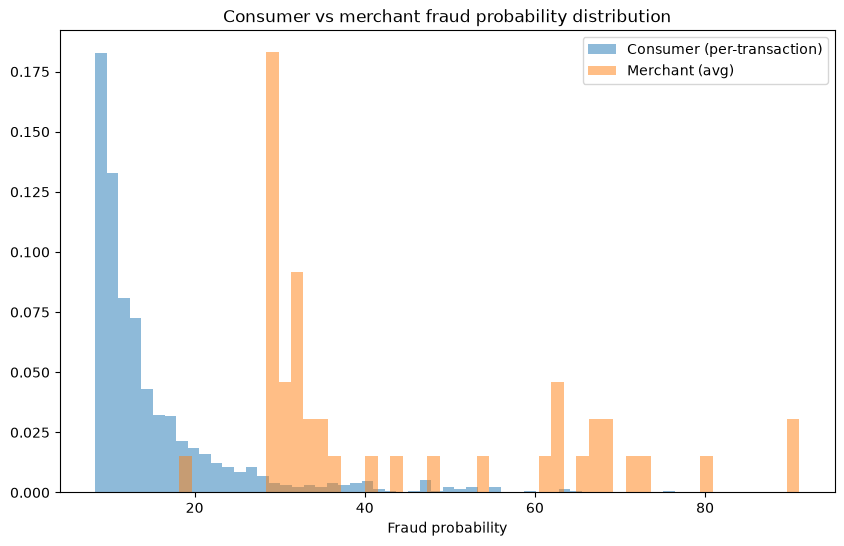

In [76]:
pdf_consumer = final_merged.select("fraud_probability").sample(0.01).toPandas()
pdf_merchant = (
    final_merged.select("merchant_abn", "avg_merchant_fraud_prob")
    .distinct()
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pdf_consumer["fraud_probability"], bins=50, alpha=0.5, label="Consumer (per-transaction)", density=True)
ax.hist(pdf_merchant["avg_merchant_fraud_prob"].dropna(), bins=50, alpha=0.5, label="Merchant (avg)", density=True)
ax.set_xlabel("Fraud probability")
ax.legend()
ax.set_title("Consumer vs merchant fraud probability distribution")
plt.show()

/tmp/ipykernel_1151/3973819333.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
/tmp/ipykernel_1151/3973819333.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)


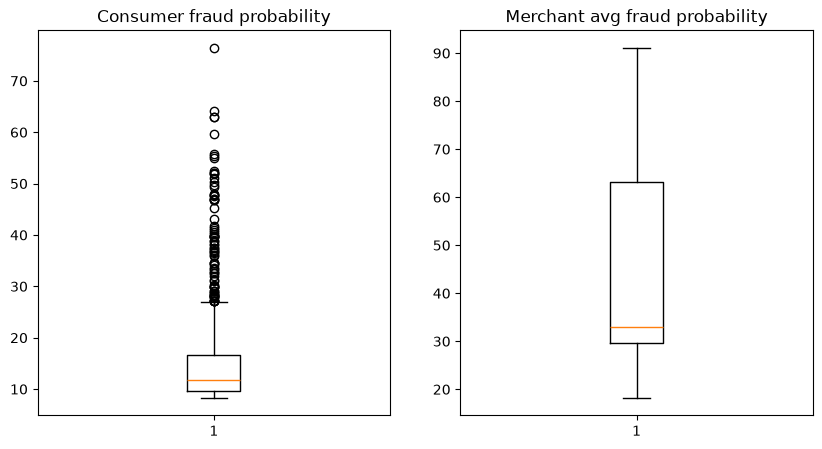

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
axes[0].set_title("Consumer fraud probability")
axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)
axes[1].set_title("Merchant avg fraud probability")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


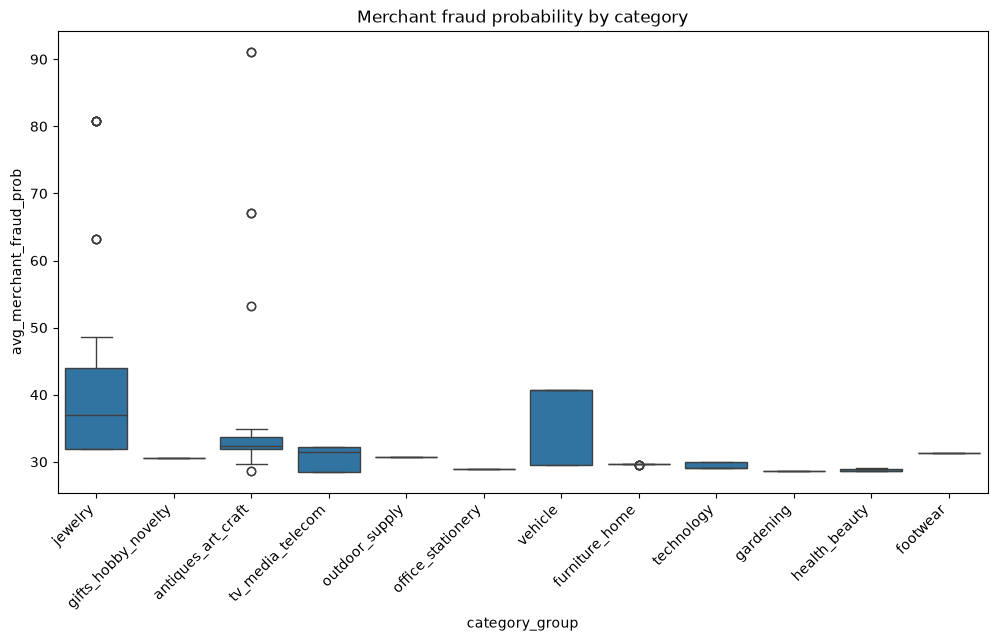

In [78]:
pdf_cat = (
    final_merged.select("category_group", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.05)
    .toPandas()
)

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf_cat, x="category_group", y="avg_merchant_fraud_prob")
plt.xticks(rotation=45, ha="right")
plt.title("Merchant fraud probability by category")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


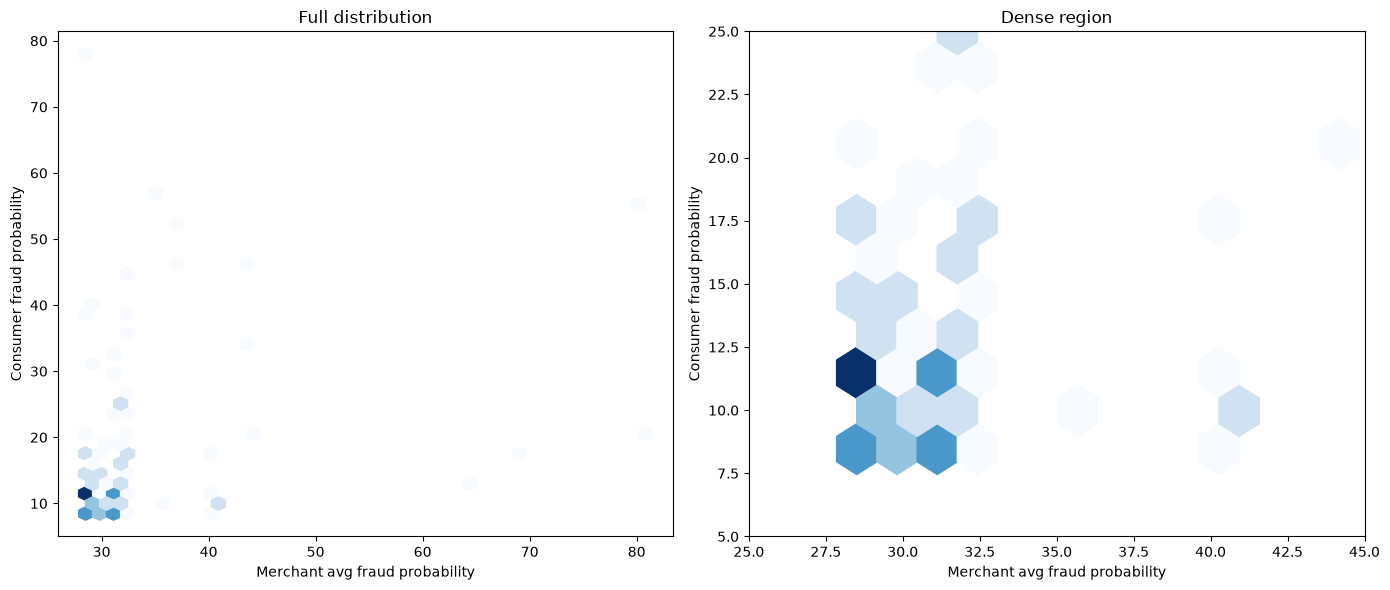

In [79]:
pdf_both = (
    final_merged.select("fraud_probability", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.01)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full range
axes[0].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[0].set_title("Full distribution")
axes[0].set_xlabel("Merchant avg fraud probability")
axes[0].set_ylabel("Consumer fraud probability")

# Zoom into dense region
axes[1].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[1].set_xlim(25, 45)
axes[1].set_ylim(5, 25)
axes[1].set_title("Dense region")
axes[1].set_xlabel("Merchant avg fraud probability")
axes[1].set_ylabel("Consumer fraud probability")

plt.tight_layout()
plt.show()

**Geospatial Analysis**

In [114]:
# formatting for geospatial plots

states_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_1_states_provinces.zip"
)

states = gpd.read_file(states_url)

states = states[
    states["admin"].str.contains("Australia", case=False, na=False)
].copy()

cities = {
    "Darwin": (130.8456, -12.4634),
    "Perth": (115.8605, -31.9505),
    "Adelaide": (138.6007, -34.9285),
    "Brisbane": (153.0251, -27.4698),
    "Sydney": (151.2093, -33.8688),
    "Canberra": (149.1300, -35.2809),
    "Melbourne": (144.9631, -37.8136),
    "Hobart": (147.3272, -42.8821),
}

city_gdf = gpd.GeoDataFrame(
    [
        {
            "city": city,
            "geometry": Point(lon, lat)
        }
        for city, (lon, lat) in cities.items()
    ],
    crs="EPSG:4326"
)

def plot_australia(
    gdf,
    column,
    title,
    cmap="magma",
    figsize=(12, 8),
    legend=True,
    state_borders=True,
    show_cities=True,
    missing_color="lightgrey",
    border_color="white",
    border_width=1.0,
    vmin=None,
    vmax=None
):
    """
    Standardised Australia choropleth map.

    Parameters
    ----------
    gdf : GeoDataFrame
        Geographic data to plot.

    column : str
        Column used to colour the map.

    title : str
        Map title.

    cmap : str
        Matplotlib colourmap.

    figsize : tuple
        Figure dimensions.

    legend : bool
        Whether to show the colour legend.

    state_borders : bool
        Whether to show state/territory borders.

    show_cities : bool
        Whether to show major city locations.
    """

    gdf_plot = gdf.to_crs("EPSG:3577")

    states_plot = states.to_crs("EPSG:3577")
    cities_plot = city_gdf.to_crs("EPSG:3577")

    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor="white"
    )

    if state_borders:
        states_plot.boundary.plot(
            ax=ax,
            color=border_color,
            linewidth=border_width,
            alpha=0.9,
            zorder=1
        )

    gdf_plot.plot(
        column=column,
        cmap=cmap,
        legend=legend,
        ax=ax,
        linewidth=0,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={
            "color": missing_color,
            "edgecolor": "white"
        },
        zorder=2
    )

    if show_cities:

        cities_plot.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.8,
            markersize=35,
            zorder=2
        )

        offsets = {
            "Darwin": (6, 6),
            "Perth": (6, 6),
            "Adelaide": (6, -14),
            "Melbourne": (6, -14),
            "Hobart": (6, -14),
            "Canberra": (6, 6),
            "Sydney": (6, 6),
            "Brisbane": (6, 6),
        }

        for _, row in cities_plot.iterrows():

            ax.annotate(
                row["city"],
                xy=(
                    row.geometry.x,
                    row.geometry.y
                ),
                xytext=offsets.get(
                    row["city"],
                    (6, 6)
                ),
                textcoords="offset points",
                fontsize=9,
                color="white",
                weight="bold",
                zorder=6,
                path_effects=[
                    pe.withStroke(
                        linewidth=2.5,
                        foreground="black"
                    )
                ]
            )

    xmin, ymin, xmax, ymax = gdf_plot.total_bounds

    xpad = (xmax - xmin) * 0.02
    ypad = (ymax - ymin) * 0.02

    ax.set_xlim(
        xmin - xpad,
        xmax + xpad
    )

    ax.set_ylim(
        ymin - ypad,
        ymax + ypad
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    ax.set_axis_off()

    plt.tight_layout()

    return fig, ax

Spend per capita grouped by postcode

In [115]:
postcode_stats = (
    final_merged
    .groupBy("postcode")
    .agg(
        F.sum("dollar_value").alias("total_spend"),
        F.count("*").alias("n_txn"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("poa_population").alias("population"),
    )
    .toPandas()
)

postcode_stats["spend_per_capita"] = postcode_stats["total_spend"] / postcode_stats["population"]

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


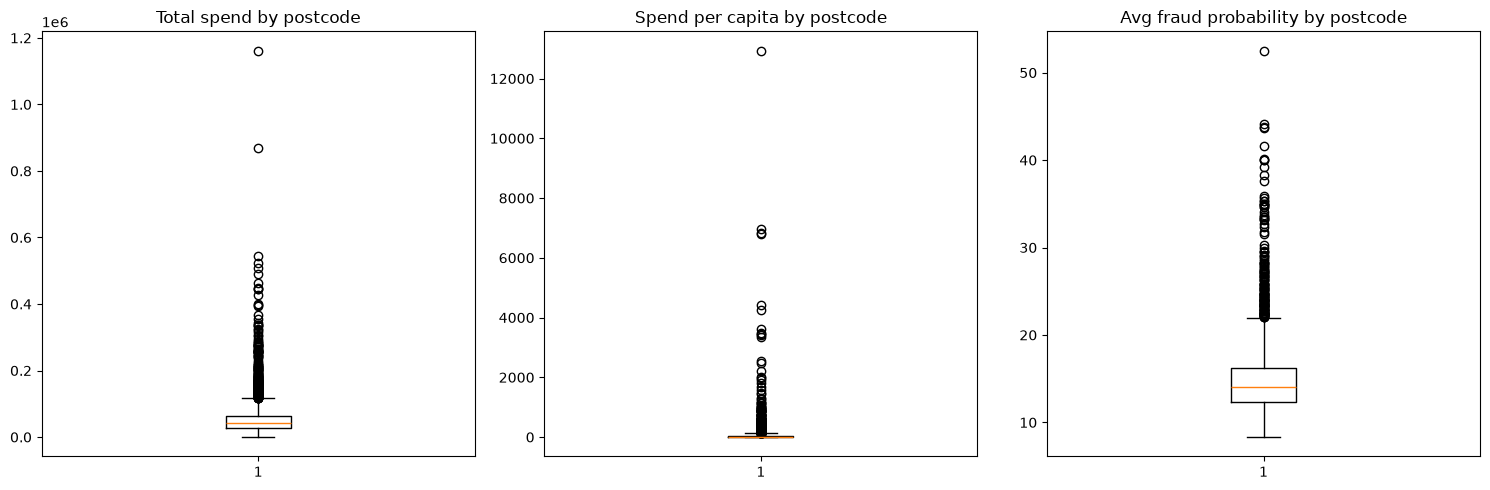

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["total_spend"].dropna())
axes[0].set_title("Total spend by postcode")

axes[1].boxplot(postcode_stats["spend_per_capita"].dropna())
axes[1].set_title("Spend per capita by postcode")

axes[2].boxplot(postcode_stats["avg_fraud_prob"].dropna())
axes[2].set_title("Avg fraud probability by postcode")

plt.tight_layout()
plt.show()

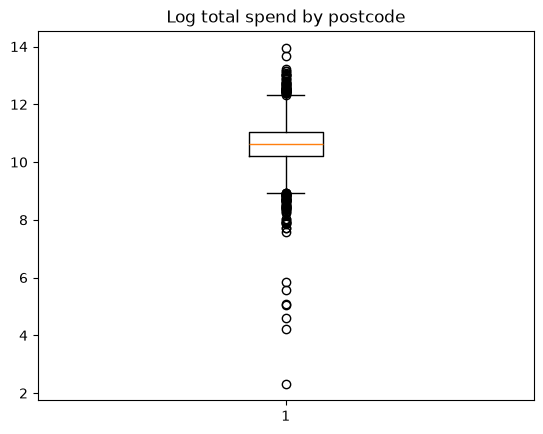

In [117]:
# transform data to fix skewness
postcode_stats["log_total_spend"] = np.log1p(postcode_stats["total_spend"])

plt.boxplot(postcode_stats["log_total_spend"].dropna())
plt.title("Log total spend by postcode")
plt.show()

In [118]:
# filter out small population
postcode_stats.sort_values("spend_per_capita", ascending=False).head(10)[["postcode", "population", "total_spend", "spend_per_capita"]]

# a) filter out unreliable small-population postcodes before computing per-capita
postcode_stats_filtered = postcode_stats[postcode_stats["population"] >= 100].copy()

# b) then log-transform what's left
postcode_stats_filtered["log_spend_per_capita"] = np.log1p(postcode_stats_filtered["spend_per_capita"])

In [119]:
poa = gpd.read_file("../data/landing/POA_2021_AUST_GDA2020.shp")[["POA_CODE21", "geometry"]]
poa = poa.rename(columns={"POA_CODE21": "postcode"})

poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

In [120]:
# for spend-per-capita and orders-per-capita maps
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

# for total spend and fraud maps (no population filter needed)
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

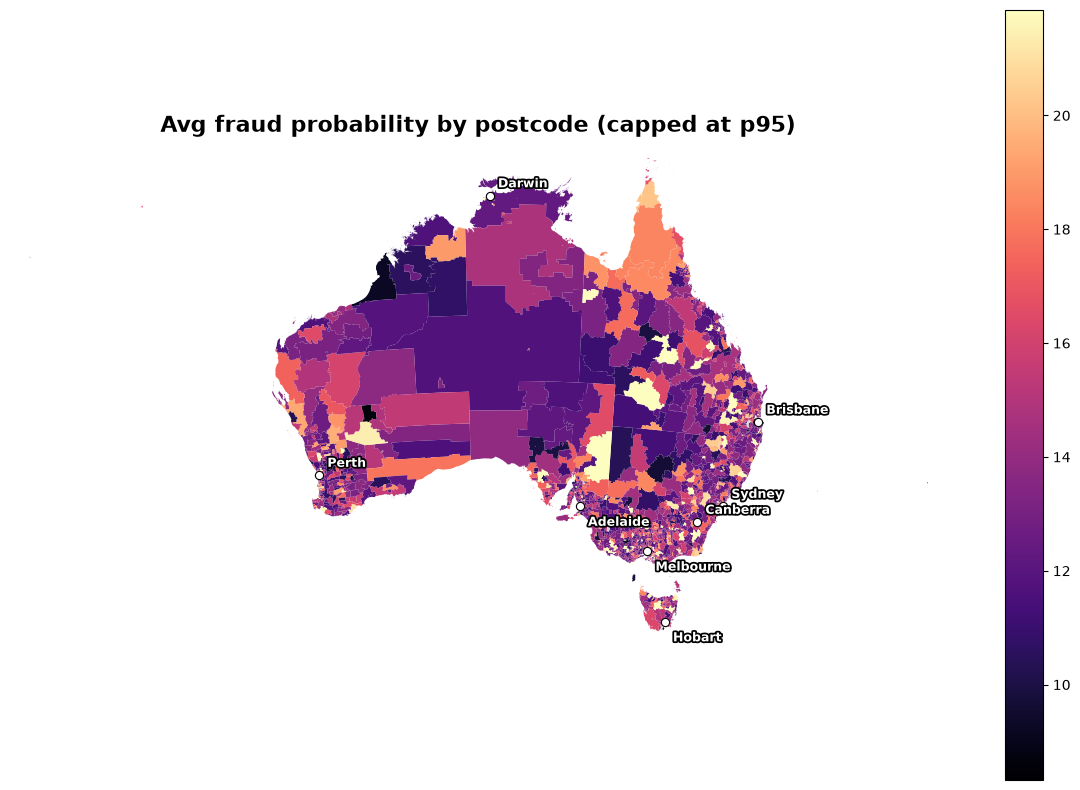

In [121]:
vmax = poa_geo["avg_fraud_prob"].quantile(0.95)

fig, ax = plot_australia(
    poa_geo,
    column="avg_fraud_prob",
    title="Avg fraud probability by postcode (capped at p95)",
    cmap="magma",
    legend=True,
    vmax=vmax
)

plt.show()

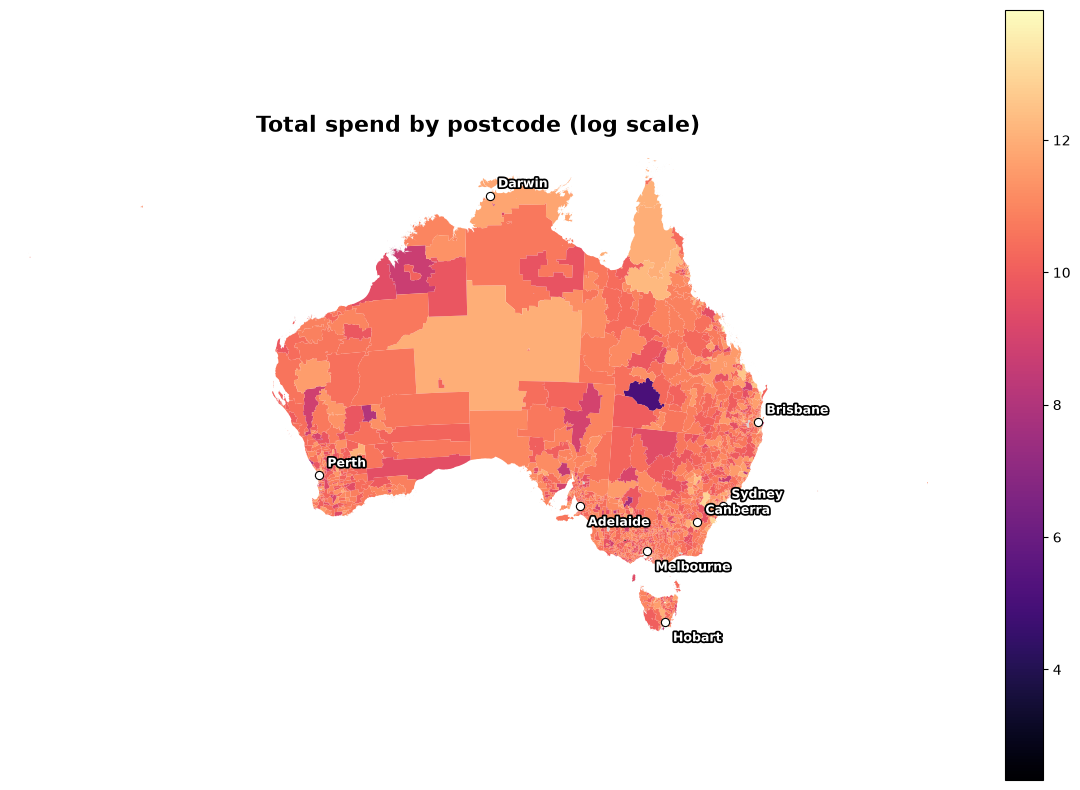

In [122]:
fig, ax = plot_australia(
    poa_geo,
    column="log_total_spend",
    title="Total spend by postcode (log scale)",
    cmap="magma",
    legend=True
)

plt.show()

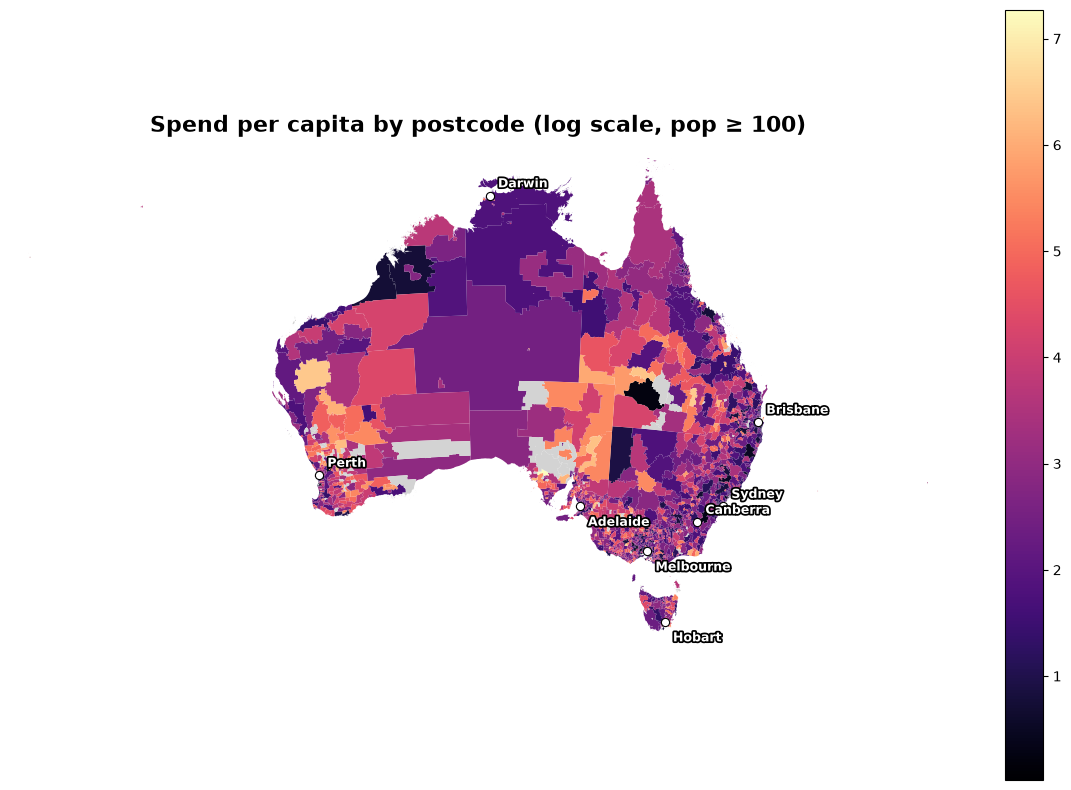

In [123]:
fig, ax = plot_australia(
    poa_geo_filtered,
    column="log_spend_per_capita",
    title="Spend per capita by postcode (log scale, pop ≥ 100)",
    cmap="magma",
    legend=True
)

plt.show()

Orders per capita grouuped by postcode

In [124]:
postcode_stats["orders_per_capita"] = postcode_stats["n_txn"] / postcode_stats["population"]
postcode_stats["log_n_txn"] = np.log1p(postcode_stats["n_txn"])

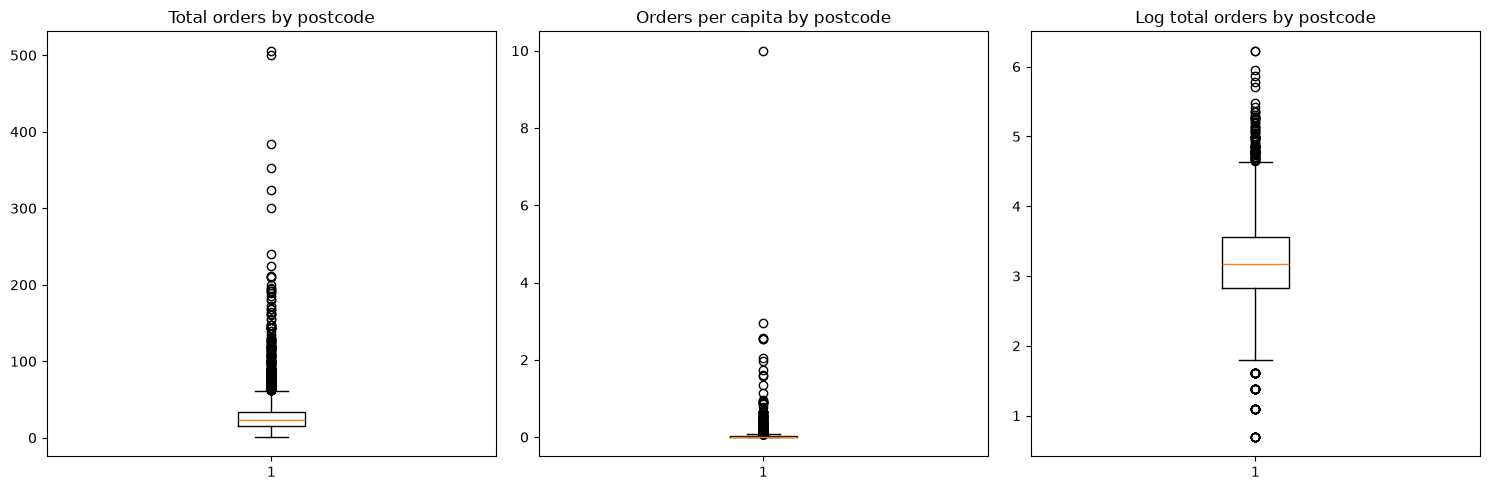

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["n_txn"].dropna())
axes[0].set_title("Total orders by postcode")

axes[1].boxplot(postcode_stats["orders_per_capita"].dropna())
axes[1].set_title("Orders per capita by postcode")

axes[2].boxplot(postcode_stats["log_n_txn"].dropna())
axes[2].set_title("Log total orders by postcode")

plt.tight_layout()
plt.show()

In [126]:
postcode_stats.sort_values("orders_per_capita", ascending=False).head(10)[
    ["postcode", "population", "n_txn", "orders_per_capita"]
]

,postcode,population,n_txn,orders_per_capita
2301,6452,4.0,40,10.000000
2456,6470,20.0,59,2.950000
1899,4479,7.0,18,2.571429
1833,6385,20.0,51,2.550000
1401,4009,11.0,28,2.545455
2251,5713,20.0,41,2.050000
2160,3415,36.0,71,1.972222
1137,6628,23.0,40,1.739130
1116,6467,30.0,48,1.600000
520,4493,19.0,30,1.578947


In [127]:
# reuse the population filter already applied for spend-per-capita
postcode_stats_filtered["orders_per_capita"] = (
    postcode_stats_filtered["n_txn"] / postcode_stats_filtered["population"]
)
postcode_stats_filtered["log_orders_per_capita"] = np.log1p(
    postcode_stats_filtered["orders_per_capita"]
)

In [128]:
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

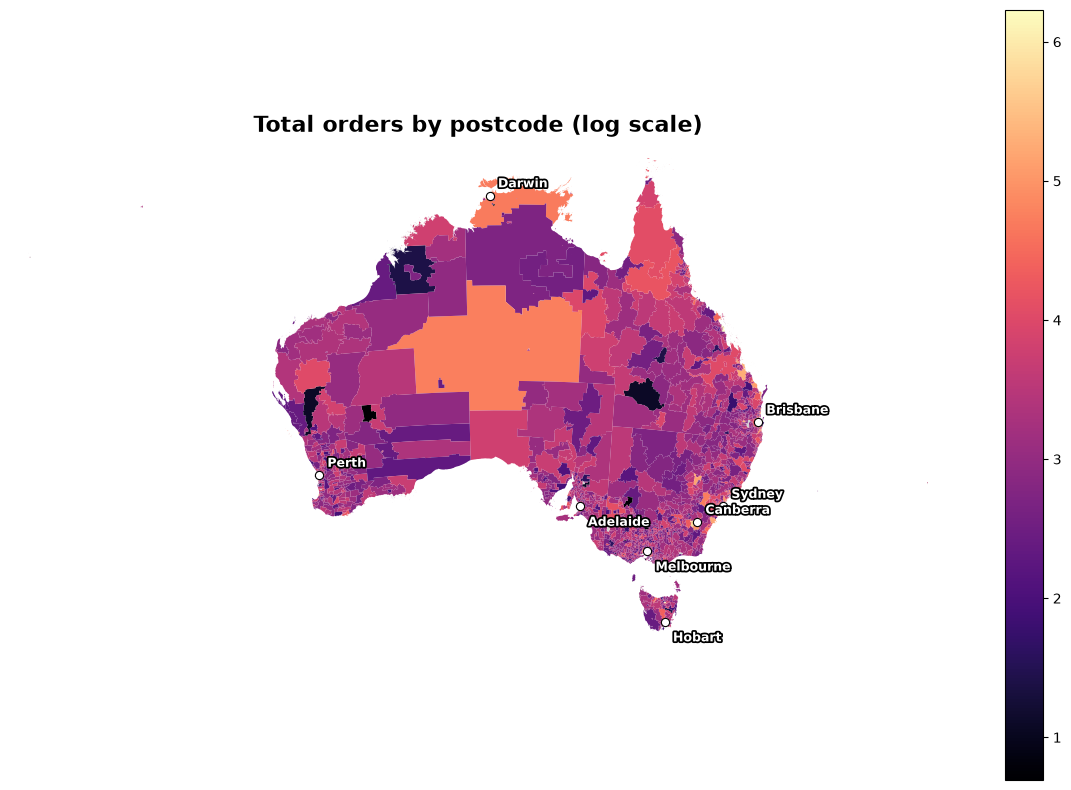

Text(1067.2777777777778, 0.5, 'log(total orders + 1)')

In [129]:
fig, ax = plot_australia(
    poa_geo,
    column="log_n_txn",
    title="Total orders by postcode (log scale)",
    cmap="magma",
    legend=True
)

plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(total orders + 1)")

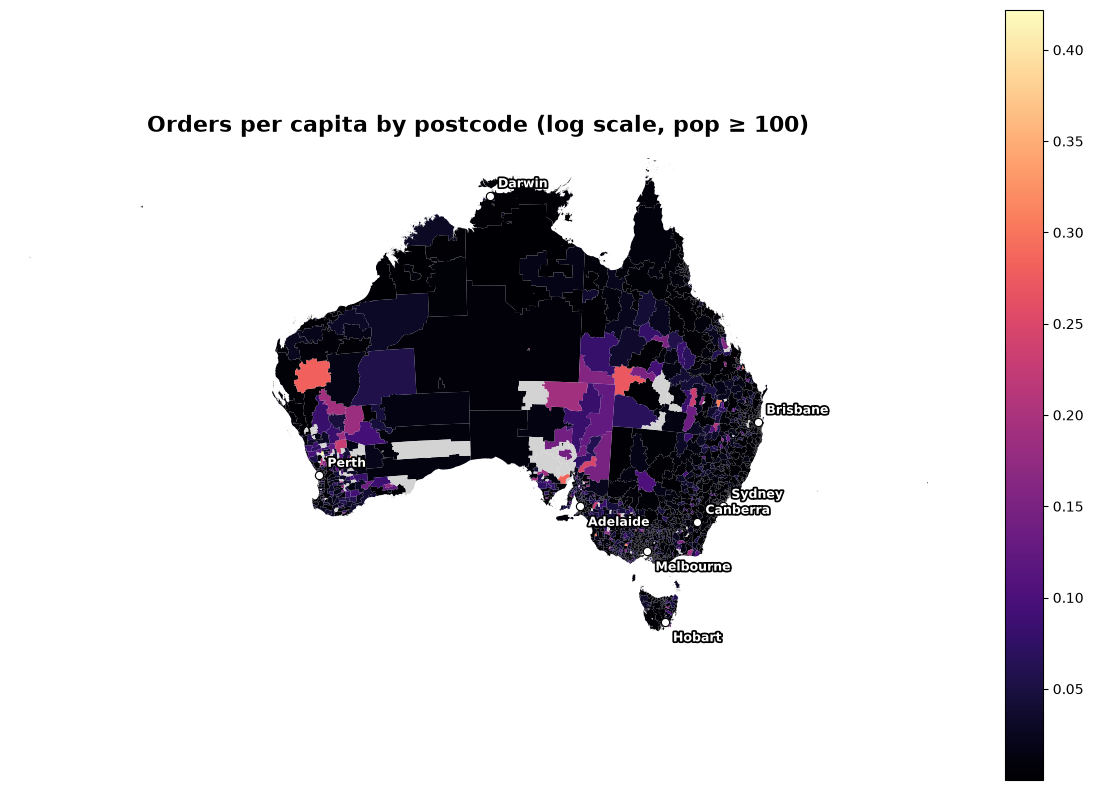

Text(1089.2777777777778, 0.5, 'log(orders per capita + 1)')

In [113]:
fig, ax = plot_australia(
    poa_geo_filtered,
    column="log_orders_per_capita",
    title="Orders per capita by postcode (log scale, pop ≥ 100)",
    cmap="magma",
    legend=True
)

plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(orders per capita + 1)")